# Part 2 — Correlation-Based / Factor-Based Multi-Omic Integration with MOFA

In this notebook we use **Multi-Omics Factor Analysis (MOFA)** to integrate transcriptomics, proteomics, and methylation data from 500 patients from TCGA-BRCA.

MOFA is best thought of as an **intermediate integration** method, also called latent-factor integration. It is not pure early integration, where all omics features are simply concatenated into one large table, and it is not pure late integration, where separate models are trained per omics layer and combined only at the end. Instead, MOFA keeps the omics views separate while learning one shared patient-level latent representation.

The main idea is that each patient has many measurements from several omics layers, and many of those measurements vary together. MOFA tries to summarize this high-dimensional variation with a small number of hidden axes called **latent factors**. These factors are learned without using the breast cancer subtype labels.

After fitting MOFA, we ask two questions:

- Do the learned factors capture subtype-associated biology?
- Which omics layers and molecular features contribute to those factors?

This notebook is written as a first introduction. You do not need prior knowledge of MOFA, factor models, or latent variable models before starting.


## Learning objectives

By the end of this notebook you should be able to:

- Explain what MOFA is and why it is useful for multi-omics integration.
- Distinguish between **views**, **groups**, **factors**, **factor values**, and **weights/loadings**.
- Load already processed and aligned omics tables.
- Use one shared train/test split for downstream evaluation.
- Fit MOFA on several molecular views to learn shared latent factors.
- Use learned factors for simple subtype prediction.
- Interpret factor plots, weight plots, variance explained plots, and subtype-associated factor activity.

The output of this notebook is a set of MOFA factors, subtype predictions, and interpretation tables that can be carried into the next workshop section.


## Conceptual primer: what does MOFA learn?

Before looking at code, it helps to name the objects that MOFA uses.

| Term | Meaning in this notebook |
| --- | --- |
| **Sample** | One patient. Each row in the omics matrices is a patient. |
| **View** | One omics layer measured on the same patients, for example transcriptomics, proteomics, or methylation. |
| **Group** | A cohort or batch of samples. Here we use one group: `TCGA-BRCA`. |
| **Feature** | One measured variable inside a view, for example a gene, protein, or methylation probe. |
| **Factor** | A hidden axis of variation learned by MOFA. A factor can represent a biological process, technical effect, subtype gradient, or other source of covariance. |
| **Factor value** | The coordinate of one patient on one factor. This answers: how strongly is this factor active in this patient? |
| **Weight / loading** | The contribution of one feature to one factor. This answers: which molecular features define this factor? |
| **Variance explained** | A summary of how much of a view, group, or feature set is reconstructed by a factor. |

A factor is not automatically a known biological pathway. It is a learned pattern. We interpret it after fitting by asking which patients have high factor values and which features have high weights.


## A small mental model

MOFA approximates each omics matrix using a low-dimensional representation:

```text
X_view ~= factor_values x view_specific_weights + noise
```

For this notebook:

- `X_view` is one molecular table, such as transcriptomics.
- `factor_values` are patient coordinates shared across views.
- `view_specific_weights` tell us how each feature in a view contributes to each factor.
- `noise` is variation not captured by the selected factors.

This is related in spirit to PCA, but MOFA is designed for **multiple omics views**. A factor can be shared across views, mostly active in one view, or weak overall. This is why MOFA is useful for integration: it gives one patient-level representation while still preserving view-specific interpretation.


**MOFA overview**



This schematic summarizes the main idea of the notebook: several omics views are integrated into shared patient-level factor values (`Z`), view-specific feature weights/loadings (`W`), and variance-explained summaries (`R2`).


## How labels are used here

MOFA itself is **unsupervised** in this notebook. The `subtype` labels are not given to MOFA during training.

We use subtype labels only after fitting, for interpretation and evaluation:

- to color factor plots,
- to test whether factors separate subtypes,
- to train a simple classifier on the learned factors,
- to measure how strongly factor values are associated with subtype.

This distinction matters. If factors align with subtype, that means the unsupervised molecular covariance structure contains subtype information.


## Expected data layout

```text
../../data_tmp/TCGA-BRCA/
├── transcriptomics.pkl
├── proteomics.pkl
└── methylation.pkl
```

Each table is assumed to be already processed, aligned, and complete. In other words, the values have already been cleaned or normalized, the same patients appear in every table, and there are no missing patient-level entries that need to be fixed here.

Assumptions used in this notebook:

- rows are patients,
- the patient ID is stored in the index, meaning the row names identify the patients rather than a separate `patient_id` column,
- `subtype` is the prediction target,
- all remaining columns are molecular features,
- all omics tables contain the same patients in the same order,
- there is no missing patient data,
- there is no imputation or preprocessing step in this tutorial.

Keeping these assumptions explicit lets us focus on the MOFA method rather than data-cleaning details.


In [1]:
# Quick environment check.
# These lines help confirm that the notebook is running on the expected machine,
# with the expected Python environment, from the expected folder.
# Reason: path or environment mismatches are common sources of errors.
import socket
import os
import sys

print("Host:", socket.gethostname())
print("Python:", sys.executable)
print("Working dir:", os.getcwd())


Host: kh061
Python: /home/bryan/miniconda3/envs/eccb2026/bin/python
Working dir: /work/gr-fe/bryan/ECCB2026_TEST/sessions/session-2-multi-omics


In [2]:
# pip install numpy pandas matplotlib ipython scikit-learn mofapy2 mofax


  Using cached mofapy2-0.7.4-py3-none-any.whl.metadata (1.9 kB)
  Using cached mofax-0.3.7-py3-none-any.whl.metadata (764 bytes)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached mofapy2-0.7.4-py3-none-any.whl (1.0 MB)
Using cached mofax-0.3.7-py3-none-any.whl (37 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [mofax]32m1/3 [mofapy2]


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.model_selection import train_test_split
from mofapy2.run.entry_point import entry_point
import mofax as mfx
import importlib


RANDOM_STATE = 42
DATA_DIR = Path("../../data_tmp/TCGA-BRCA")
TARGET_COLUMN = "subtype"
GENE_SYMBOL_MAP_FILE = DATA_DIR.parent / "ensembl_gene_symbol_map_hgnc.csv"
OUTPUT_DIR = Path("outputs").resolve()

OMICS_FILES = {
    "transcriptomics": DATA_DIR / "transcriptomics.pkl",
    "proteomics": DATA_DIR / "proteomics.pkl",
    "methylation": DATA_DIR / "methylation.pkl",
}

TEST_SIZE = 0.25
N_TOP_VARIABLE_HIGH_DIM_FEATURES = 2000
HIGH_DIMENSIONAL_VIEWS = ["transcriptomics", "methylation"]
MAX_FACTORS = 10
MIN_TOTAL_R2 = 2.5
MOFA_ITERATIONS = 500
LOAD_MOFA_HDF5 = True
SAVE_MOFA_HDF5 = True
MOFA_HDF5_FILE = OUTPUT_DIR / f"trained_mofaplus_train_var{N_TOP_VARIABLE_HIGH_DIM_FEATURES}_max{MAX_FACTORS}_ard_model.hdf5"

# Map Ensembl gene IDs to gene symbols for readable transcriptomics labels in weight tables/plots.
if GENE_SYMBOL_MAP_FILE.exists():
    gene_symbol_table = pd.read_csv(GENE_SYMBOL_MAP_FILE)
    gene_symbol_map = dict(zip(gene_symbol_table["ensembl_gene_id"], gene_symbol_table["symbol"]))
else:
    gene_symbol_map = {}


**Parameter choices.**

`N_TOP_VARIABLE_HIGH_DIM_FEATURES = 2000` keeps the 2,000 most variable features from the high-dimensional views, here transcriptomics and methylation. Proteomics has far fewer features, so we keep all proteins. The variable-feature selection is computed on the training patients only and then the same selected features are used for the test patients.

`MAX_FACTORS = 10` is now an **upper bound**, not the final number of factors we force ourselves to interpret. MOFA starts with up to 10 latent factors, and `ard_factors=True` lets the model shrink factors that explain little signal. After fitting, we use MOFA's R2 output to keep only the active factors with total R2 above `MIN_TOTAL_R2`. This is a practical automatic-selection strategy for the workshop: start slightly generous, then let the fitted model and variance explained decide which factors are worth keeping.

`MIN_TOTAL_R2 = 2.5` is the cutoff used to decide whether a factor is active. Here, a factor must explain at least about 2.5% total R2 across the omics views to be kept for the classifier and interpretation plots. In a real analysis, this threshold should be checked together with factor stability and biological interpretability.

`MOFA_ITERATIONS` controls the maximum number of training iterations. More iterations give the model more time to converge, but also make the notebook slower. Here we use `500`, which is more realistic than a very short test run but can still be reduced temporarily if you only want to check that the notebook runs.

`MOFA_HDF5_FILE` is the absolute HDF5 path used to store and reload the **training-only** MOFA model. The filename includes the variable-feature setting, `MAX_FACTORS`, and `ard` so we do not accidentally reload an older model fitted with different settings. If `LOAD_MOFA_HDF5 = True` and this file already exists, the notebook reloads it directly in Python with `mofax`, using `mofa_model = mfx.mofa_model(str(MOFA_HDF5_FILE))`. If the file does not exist, MOFA is fitted with `mofapy2` on training patients only and then saved to this HDF5 path. The notebook also prepares `mofa_model_mfx`, a `mofax` version of the model used later for projection, R2, factor, and weight outputs.


## 1. Load the already processed omics tables

We start from preprocessed matrices so that the first methodological question is clear: how can we integrate several omics layers measured on the same patients?

At this stage, we separate the data into two objects:

- `X_omics`: the molecular views used by MOFA,
- `y`: the subtype labels used later for interpretation and prediction.

MOFA will only see `X_omics`. It will not see `y`.


In [8]:
# Load the pre-aligned multi-omics object used in this session.
# It is a dictionary: one entry per omics layer plus a "meta" entry for labels.
omics = pd.read_pickle(DATA_DIR / "omics.pkl")

type(omics) # dict
omics.keys() # dict_keys(['transcriptomics', 'proteomics', 'methylation', 'meta'])

# The aligned pickle stores subtype labels separately from the omics matrices.
# We keep the label index as the reference patient order for all later checks.
y = omics["meta"].astype(str)
patient_ids = y.index.astype(str)

# Keep only molecular data matrices in X_omics; "meta" is the prediction target.
X_omics = {
    name: df
    for name, df in omics.items()
    if name != "meta"
}

# Confirm the workshop assumptions without changing the data.
# Each matrix should contain the same patients, in the same order, as the labels.
for name, df in X_omics.items():
    print(f"{name:15s}: {df.shape[0]:4d} patients × {df.shape[1]:6d} molecular features")
    assert df.index.astype(str).equals(patient_ids), f"Patient index differs in {name}"

print("\n Subtype counts:")
display(y.value_counts().rename("n_patients").to_frame())


transcriptomics:  500 patients ×  29995 molecular features
proteomics     :  500 patients ×    464 molecular features
methylation    :  500 patients × 200000 molecular features

 Subtype counts:


,n_patients
paper_BRCA_Subtype_PAM50,
LumA,237
LumB,100
Basal,97
Her2,41
Normal,25


## 2. Create one shared train/test split and select variable features

MOFA is unsupervised, so it does not require a train/test split in the same way that a supervised classifier does. We still create a split because later we will ask whether the learned factors can predict subtype in held-out patients.

The split is patient-level and shared by every omics layer. This avoids a common mistake in multi-omics analysis: accidentally training on one view for a patient while testing on another view from the same patient.

After splitting, we reduce the very high-dimensional views by keeping the most variable features in the training set. This helps with runtime and reduces the chance that methylation or transcriptomics dominate MOFA only because they contain far more measured features than proteomics.


In [9]:
# Create one patient-level split shared by every omics layer.
# Stratification keeps the subtype proportions similar in train and test sets.
train_ids, test_ids = train_test_split(
    patient_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Store the split as named pandas indexes so .loc selects patients explicitly.
train_ids = pd.Index(train_ids, name="patient_id")
test_ids = pd.Index(test_ids, name="patient_id")

# First split each molecular matrix by patient.
X_train_raw = {name: X.loc[train_ids] for name, X in X_omics.items()}
X_test_raw = {name: X.loc[test_ids] for name, X in X_omics.items()}

# Select the most variable features in the training set for high-dimensional views only.
# The test set is filtered to the same selected columns; test patients are not used to choose features.
selected_features_by_view = {}
X_train_omics = {}
X_test_omics = {}

for name, X_train_view in X_train_raw.items():
    if name in HIGH_DIMENSIONAL_VIEWS:
        n_top = min(N_TOP_VARIABLE_HIGH_DIM_FEATURES, X_train_view.shape[1])
        feature_variance = X_train_view.var(axis=0)
        selected_features = feature_variance.sort_values(ascending=False).head(n_top).index
    else:
        selected_features = X_train_view.columns

    selected_features_by_view[name] = selected_features.astype(str).tolist()
    X_train_omics[name] = X_train_view.loc[:, selected_features]
    X_test_omics[name] = X_test_raw[name].loc[:, selected_features]

# Split the labels with the same patient IDs used for the omics data.
y_train = y.loc[train_ids]
y_test = y.loc[test_ids]

print(f"Training patients: {len(train_ids)}")
print(f"Test patients:     {len(test_ids)}")

# Check that the stratified split kept subtype proportions similar in train and test.
split_balance = pd.DataFrame(
    {
        "all_n": y.value_counts().sort_index(),
        "train_n": y_train.value_counts().sort_index(),
        "test_n": y_test.value_counts().sort_index(),
    }
).fillna(0).astype(int)
split_balance["all_%"] = (100 * split_balance["all_n"] / split_balance["all_n"].sum()).round(1)
split_balance["train_%"] = (100 * split_balance["train_n"] / split_balance["train_n"].sum()).round(1)
split_balance["test_%"] = (100 * split_balance["test_n"] / split_balance["test_n"].sum()).round(1)

print("\nSubtype balance after stratified split:")
display(split_balance)

print("\n Feature counts after variance filtering:")
for name in X_omics:
    print(
        f"{name:15s}: {X_omics[name].shape[1]:6d} original -> "
        f"{X_train_omics[name].shape[1]:6d} used for MOFA"
    )


Training patients: 375
Test patients:     125

Subtype balance after stratified split:


,all_n,train_n,test_n,all_%,train_%,test_%
paper_BRCA_Subtype_PAM50,,,,,,
Basal,97,73,24,19.4,19.5,19.2
Her2,41,31,10,8.2,8.3,8.0
LumA,237,177,60,47.4,47.2,48.0
LumB,100,75,25,20.0,20.0,20.0
Normal,25,19,6,5.0,5.1,4.8



 Feature counts after variance filtering:
transcriptomics:  29995 original ->   2000 used for MOFA
proteomics     :    464 original ->    464 used for MOFA
methylation    : 200000 original ->   2000 used for MOFA


## 3. Helper functions for evaluation

The classifier used later is intentionally simple: multinomial logistic regression on top of MOFA factors.

The workflow is: first fit MOFA without using subtype labels, then extract one factor-value table with patients as rows and latent factors as columns. We start with up to `MAX_FACTORS` factors, then keep the active factors selected from MOFA's R2 output. Each patient is therefore represented by a compact set of selected factor values, not by separate omics matrices. The classifier receives this patient-by-factor table and learns whether those factor values are predictive of subtype.

You can think of the classifier as a small supervised layer on top of the unsupervised MOFA representation. It does not change the MOFA factors; it only tests whether the factors contain information that is useful for prediction.

Other models could be used here, for example random forests, support vector machines, k-nearest neighbors, gradient boosting, or a small neural network. We use logistic regression because it is simple, fast, and easier to interpret. Although logistic regression is often introduced for binary outcomes, scikit-learn can fit **multinomial logistic regression**, which handles several classes such as the breast cancer subtypes used here.

This choice keeps the interpretation clean. If a simple classifier performs well on a small number of factors, the factors themselves contain subtype-relevant information. We are not trying to optimize the best possible subtype predictor here; we are using prediction as a diagnostic for the representation learned by MOFA.


In [10]:
def evaluate_predictions(y_true, y_pred, model_name):
    """Return common classification metrics in one row."""
    # Accuracy is easy to read, while balanced accuracy and macro-F1
    # give each subtype more equal influence when classes are imbalanced.
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


def fit_factor_classifier(factors_df, y, train_ids, test_ids, model_name):
    """Fit a classifier on training factors and evaluate on held-out test factors."""
    # Train on low-dimensional factors rather than the original high-dimensional omics.
    # Balanced class weights reduce the bias toward larger subtype groups.
    clf = LogisticRegression(
        max_iter=2000,              # allow enough optimization steps for the model to converge
        class_weight="balanced",    # give smaller subtype classes more weight during training
        random_state=RANDOM_STATE,  
    )
    # Use only training patients for fitting, then predict on held-out patients.
    clf.fit(factors_df.loc[train_ids], y.loc[train_ids])
    pred = clf.predict(factors_df.loc[test_ids])
    # Package all test-set metrics in a consistent format for comparison later.
    metrics = evaluate_predictions(y.loc[test_ids], pred, model_name)
    return clf, pred, metrics


## 4. Prepare the MOFA input

`mofapy2` expects data in a nested structure: **views** by **groups**.

In this notebook:

- views are the omics layers: transcriptomics, proteomics, and methylation,
- there is one group: `TCGA-BRCA`,
- each view contains a patient-by-feature matrix.

The same patient IDs are used across all views. This alignment is essential: MOFA learns patient-level factors by comparing how the different omics layers co-vary across the same samples.

The `subtype` labels are not included in this object. They are kept aside until after MOFA has learned the latent factors.

At this point, transcriptomics and methylation have already been reduced to their most variable training-set features. Proteomics is kept unchanged because it already has a much smaller number of features.


In [11]:
def build_mofa_matrix_input(X_by_omic):
    """Convert aligned omics DataFrames to the nested matrix format expected by mofapy2."""
    # MOFA calls each omics layer a "view" and each patient cohort a "group".
    # Here we have several views, but only one group: the TCGA-BRCA training patients.
    data = []
    view_names = []
    feature_names = []

    # All views must contain the same patients in the same order.
    mofa_sample_ids = next(iter(X_by_omic.values())).index.astype(str)

    for view_name, X in X_by_omic.items():
        assert X.index.astype(str).equals(mofa_sample_ids), f"Patient index differs in {view_name}"
        view_names.append(view_name)
        feature_names.append(X.columns.astype(str).tolist())
        # mofapy2 expects data[view][group] = samples x features matrix.
        data.append([X.to_numpy(dtype=np.float32)])  # one group, many views

    # Sample names are nested by group; all views share the same training patients.
    sample_names = [mofa_sample_ids.tolist()]
    group_names = ["TCGA-BRCA_train"]

    return data, view_names, feature_names, sample_names, group_names


# Build the objects passed directly into the MOFA entry point below.
# For strict prediction, MOFA is fitted on training patients only.
mofa_data, view_names, feature_names, sample_names, group_names = build_mofa_matrix_input(X_train_omics)

# Quick shape check: each view should have the same number of training patients.
# Also print a tiny preview so we can see what is being passed to MOFA.
for view_idx, (view_name, matrix) in enumerate(zip(view_names, mofa_data)):
    view_matrix = matrix[0]  # one group: TCGA-BRCA_train
    print(f"\n {view_name:15s}: {view_matrix.shape}")
    print("  first 3 training patients:", sample_names[0][:3])
    print("  first 3 features:", feature_names[view_idx][:3])
    print("  first 3 x 3 values:")
    print(view_matrix[:3, :3])
    print()

print("\n Group names", group_names)



 transcriptomics: (375, 2000)
  first 3 training patients: ['TCGA-S3-AA0Z', 'TCGA-E9-A1N6', 'TCGA-C8-A26Y']
  first 3 features: ['ENSG00000110484.7', 'ENSG00000166509.12', 'ENSG00000153002.12']
  first 3 x 3 values:
[[6.5552697 2.8434672 5.016912 ]
 [5.556552  8.19825   6.1988907]
 [5.6827602 4.590756  2.8434672]]


 proteomics     : (375, 464)
  first 3 training patients: ['TCGA-S3-AA0Z', 'TCGA-E9-A1N6', 'TCGA-C8-A26Y']
  first 3 features: ['1433BETA', '1433EPSILON', '1433ZETA']
  first 3 x 3 values:
[[ 0.022889  0.25171   0.27433 ]
 [ 0.30788   0.22643  -0.16134 ]
 [ 0.23062  -0.075639 -0.44508 ]]


 methylation    : (375, 2000)
  first 3 training patients: ['TCGA-S3-AA0Z', 'TCGA-E9-A1N6', 'TCGA-C8-A26Y']
  first 3 features: ['cg11738485', 'cg12466610', 'cg01893212']
  first 3 x 3 values:
[[0.01856231 0.03304229 0.02396981]
 [0.9842885  0.04287856 0.6445241 ]
 [0.79413193 0.97176045 0.03665907]]


 Group names ['TCGA-BRCA_train']


## 5. Fit MOFA

MOFA learns a small number of latent factors that explain covariance structure across the molecular views.

During fitting, MOFA estimates two main things:

- **factor values**: where each patient sits on each latent factor,
- **weights/loadings**: which features in each omics view define each factor.

The model options below control the maximum number of factors and how sparse the feature weights can be. Sparsity is useful because a factor is easier to interpret when it is driven by a smaller set of strong features rather than by tiny contributions from every feature.

For this workshop, `MOFA_ITERATIONS` is kept small enough that the notebook remains practical to run. In a production analysis, you would typically use more iterations and check convergence more carefully.

**How many factors should we use?**

Here `MAX_FACTORS = 10` is the starting upper bound. Instead, we fit a compact model, enable factor-level ARD, and then use the variance explained table to keep only factors with enough signal. This is a common practical workflow: allow the model room to find structure, then interpret the active factors rather than every initialized factor.

**What does training optimize?**

MOFA fits a probabilistic model by variational inference. For this workshop, you do not need the mathematical details. The practical point is that the model searches for latent factors and weights that reconstruct the observed omics matrices while accounting for noise and encouraging simpler structure when sparsity options are enabled.


In [12]:
def fit_mofa(data, view_names, feature_names, sample_names, group_names):
    """Fit a compact MOFA model and return the trained entry point object."""
    model = entry_point()

    # These are MOFA's internal centering/scaling controls, not external preprocessing.
    # scale_views=True helps prevent one view from dominating only because it has a larger scale.
    model.set_data_options(
        scale_views=True,   # put views on comparable scales before fitting
        scale_groups=False, # no group scaling needed because we only have one group: TCGA-BRCA_train
        center_groups=True, # center samples within each group
        use_float32=True,   # reduce memory use for large omics matrices
    )

    # Register the nested matrices and their names with MOFA.
    # Gaussian likelihood is appropriate here because the inputs are continuous values.
    model.set_data_matrix(
        data=data,                                  # nested matrices: data[view][group]
        likelihoods=["gaussian"] * len(view_names), # one likelihood per omics view
        views_names=view_names,                     # names of the omics layers
        groups_names=group_names,                   # names of patient cohorts/groups
        samples_names=sample_names,                 # patient IDs, nested by group
        features_names=feature_names,               # molecular feature names per view
    )

    # MAX_FACTORS is an upper bound. ARD lets MOFA shrink factors that explain little signal,
    # and we later keep only active factors based on the official MOFA R2 output.
    model.set_model_options(
        factors=MAX_FACTORS,       # maximum number of latent factors to learn
        spikeslab_factors=False,   # do not switch whole factors on/off per group
        spikeslab_weights=True,    # allow sparse feature weights within each view
        ard_factors=True,          # shrink weak/redundant factors automatically
        ard_weights=True,          # down-weight views/features that explain little signal
    )

    # Use a short, reproducible training run suitable for an interactive notebook.
    model.set_train_options(
        iter=MOFA_ITERATIONS,    # maximum number of training iterations
        convergence_mode="fast", # faster convergence checks for the workshop runtime
        seed=RANDOM_STATE,       # make the fitted factors reproducible
        verbose=False,           # suppress detailed training logs
        quiet=True,              # keep notebook output compact
        outfile=str(MOFA_HDF5_FILE) if SAVE_MOFA_HDF5 else None, # standard HDF5 output path
    )

    # build() prepares the model graph; run() performs the actual variational training.
    model.build()
    model.run()

    # In some environments, passing outfile in set_train_options is not enough to leave
    # the HDF5 exactly where mofax will reload it. Save explicitly if needed.
    if SAVE_MOFA_HDF5 and not MOFA_HDF5_FILE.exists():
        model.save(outfile=str(MOFA_HDF5_FILE))

    return model

# Load the training-only HDF5 directly in Python with mofax if it already exists.
# Otherwise, fit MOFA on training patients with mofapy2 and ask MOFA to write the HDF5 outfile.
if LOAD_MOFA_HDF5 and MOFA_HDF5_FILE.exists():
    mofa_model = mfx.mofa_model(str(MOFA_HDF5_FILE))
    print(f"Loaded MOFA model from: {MOFA_HDF5_FILE}")
else:
    if SAVE_MOFA_HDF5:
        OUTPUT_DIR.mkdir(exist_ok=True)
    mofa_model = fit_mofa(mofa_data, view_names, feature_names, sample_names, group_names)
    if SAVE_MOFA_HDF5 and MOFA_HDF5_FILE.exists():
        print(f"Saved MOFA model to: {MOFA_HDF5_FILE}")
    elif SAVE_MOFA_HDF5:
        print(f"Warning: MOFA finished, but expected HDF5 file was not found at: {MOFA_HDF5_FILE}")


# Keep a mofax view of the trained model for standard MOFA outputs such as R2.
# When the model was fitted with mofapy2 above, reload the saved HDF5 with mofax.
if hasattr(mofa_model, "get_r2") and hasattr(mofa_model, "get_weights"):
    mofa_model_mfx = mofa_model
elif MOFA_HDF5_FILE.exists():
    mofa_model_mfx = mfx.mofa_model(str(MOFA_HDF5_FILE))
else:
    raise FileNotFoundError(
        "MOFA standard outputs and projections are read with mofax from the trained HDF5 file. "
        "Set SAVE_MOFA_HDF5 = True and rerun the MOFA fitting cell first."
    )



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

Scaling views to unit variance...

Successfully loaded view='transcriptomics' group='TCGA-BRCA_train' with N=375 samples and D=2000 features...
Successfully loaded view='proteomics' group='TCGA-BRCA_train' with N=375 samples and D=464 features...
Successfully loaded view='methylation' group

### Correlation between factors

A good sanity check is to verify that the Factors are largely uncorrelated. In MOFA there are no orthogonality constraints such as in Principal Component Analysis, but if there is a lot of correlation between Factors this suggests a poor model fit. Reasons? Perhaps you used too many factors or perhaps the normalisation is not adequate.


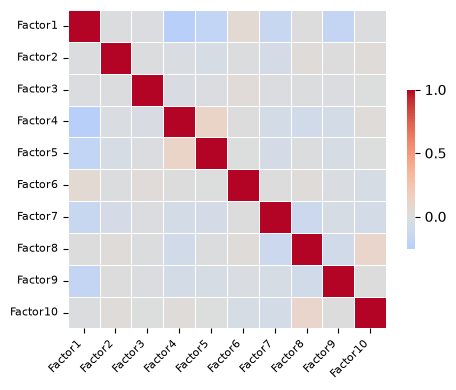

In [13]:
ax = mfx.plot_weights_correlation(
    mofa_model_mfx,
    views=view_names,
    cmap="coolwarm",
)

ax.figure.set_size_inches(5, 4)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=8,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=8,
)

plt.tight_layout()
plt.show()

**Discussion of the factor weight correlation plot.**

This heatmap compares MOFA factors using their feature-weight profiles. In other words, it asks whether two factors are defined by similar molecular features across the omics views.

The diagonal is equal to 1 because each factor is perfectly correlated with itself. The important part is therefore the off-diagonal cells. Here, most off-diagonal correlations are close to zero, which suggests that the factors are largely defined by different loading patterns rather than all reusing the same molecular signal.

There are a few mild relationships, for example a positive correlation between `Factor4` and `Factor5`, and another between `Factor8` and `Factor10`. These are not strong enough to suggest that the factors are duplicates, but they indicate that some factors may share part of their feature-weight structure. Overall, this plot is reassuring: the learned factors look mostly distinct, so it makes sense to inspect them separately in the following sections.


## 6. Inspect variance explained (`R2`): which views are reconstructed by the training-fitted factors?

We start interpretation with variance explained because it gives a quick global check of which views are reconstructed by the factors learned from the training patients. Variance explained plots help answer: **where does this factor matter most?**

Here we use the variance explained values stored in the training-fitted MOFA HDF5 model and read them with `mofax`. 

Difference from MOFA weight view contributions: weights tell us which features/views define the factor; MOFA R2 asks **how much variance in each omics view is explained by the factor**, using the fitted MOFA model. A view can have some strong feature weights but still explain only a modest fraction of the total view variance.

`mofax` reports R2 as a percentage. For example, an R2 of `15` means that the factor explains about 15% of the variance for that view/group combination.


In [14]:
# mofax returns the official variance-explained table stored in the trained model.
r2_all = mofa_model_mfx.get_r2().rename(
    columns={
        "Factor": "factor",
        "View": "view",
        "Group": "group_mofax",
        "R2": "r2",
    }
)
r2_all["group"] = "all"
r2_all = r2_all[["view", "group", "factor", "r2", "group_mofax"]]

# Automatic factor selection: sum each factor's R2 across views and keep factors above a small cutoff.
factor_r2_summary = (
    r2_all
    .groupby("factor", as_index=False)["r2"]
    .sum()
    .rename(columns={"r2": "total_r2"})
    .sort_values("total_r2", ascending=False)
)

active_factor_summary = factor_r2_summary[factor_r2_summary["total_r2"] >= MIN_TOTAL_R2].copy()
if active_factor_summary.empty:
    active_factor_summary = factor_r2_summary.head(1).copy()

active_factor_cols = active_factor_summary["factor"].tolist()
active_factor_numbers = [int("".join(ch for ch in factor if ch.isdigit())) for factor in active_factor_cols]
active_factor_indices = [number - 1 for number in active_factor_numbers]
active_factors_mfx = active_factor_cols

print(f"Selected {len(active_factor_cols)} active factors out of {MAX_FACTORS} initialized factors.")
display(factor_r2_summary)
display(r2_all.head())


Selected 10 active factors out of 10 initialized factors.


,factor,total_r2
0,Factor1,40.338886
2,Factor2,23.963904
3,Factor3,17.232335
4,Factor4,11.070335
5,Factor5,9.156364
6,Factor6,6.411213
7,Factor7,5.935544
8,Factor8,4.531199
9,Factor9,4.527390
1,Factor10,3.880328


,view,group,factor,r2,group_mofax
0,transcriptomics,all,Factor1,5.058134,TCGA-BRCA_train
1,proteomics,all,Factor1,2.607805,TCGA-BRCA_train
2,methylation,all,Factor1,32.672948,TCGA-BRCA_train
3,transcriptomics,all,Factor2,13.057315,TCGA-BRCA_train
4,proteomics,all,Factor2,6.988317,TCGA-BRCA_train


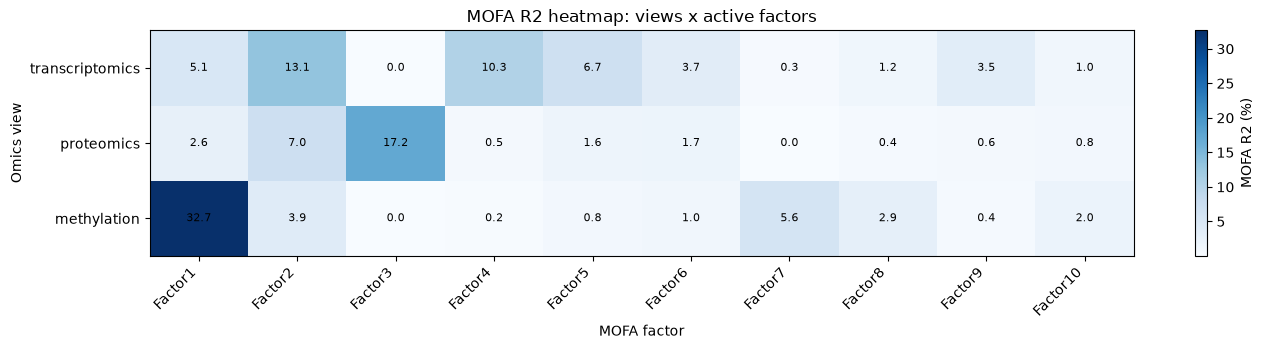

In [15]:
# Built-in mofax heatmap of variance explained.
mfx.plot_r2(
    mofa_model_mfx,
    x="Factor",
    y="View",
    factors=active_factor_indices,
    cmap="Blues",
)
plt.show()

# Annotated R2 heatmap: views x active factors.
# This compact matrix is one of the most common first diagnostics for a MOFA model.
r2_heatmap = (
    r2_all[r2_all["factor"].isin(active_factor_cols)]
    .pivot(index="view", columns="factor", values="r2")
    .reindex(index=view_names, columns=active_factor_cols)
)

fig, ax = plt.subplots(figsize=(1.1 * len(active_factor_cols) + 3, 3.6))
im = ax.imshow(r2_heatmap, aspect="auto", cmap="Blues")

ax.set_title("MOFA R2 heatmap: views x active factors")
ax.set_xlabel("MOFA factor")
ax.set_ylabel("Omics view")
ax.set_xticks(range(r2_heatmap.shape[1]))
ax.set_xticklabels(r2_heatmap.columns, rotation=45, ha="right")
ax.set_yticks(range(r2_heatmap.shape[0]))
ax.set_yticklabels(r2_heatmap.index)

for row in range(r2_heatmap.shape[0]):
    for col in range(r2_heatmap.shape[1]):
        value = r2_heatmap.iloc[row, col]
        if pd.notna(value):
            ax.text(col, row, f"{value:.1f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="MOFA R2 (%)")
plt.tight_layout()
plt.show()


**Discussion of the overall R2 heatmaps.**

These heatmaps show the official MOFA variance explained values read with `mofax`. They ask how much variance each training-fitted factor explains in each omics view. Darker blue means a larger MOFA R2 percentage, so that factor explains more of that view.

The annotated heatmap is useful because it immediately separates view-specific and shared factors. `Factor1` is the strongest signal overall and is mainly driven by methylation, explaining about `32.7%` of methylation variance, with smaller contributions in transcriptomics (`5.1%`) and proteomics (`2.6%`). `Factor2` is more multi-view: it explains transcriptomics best (`13.1%`), but also contributes to proteomics (`7.0%`) and methylation (`3.9%`). `Factor3` is almost entirely proteomics-driven (`17.2%`) and contributes essentially nothing to transcriptomics or methylation.

Other factors explain more modest amounts of variance. For example, `Factor4` and `Factor5` are mostly transcriptomics-associated, while `Factor7` is mostly methylation-associated. Factors with small R2 values are not automatically useless: they may still separate subtypes or highlight specific feature patterns, but they should be interpreted more cautiously than the dominant factors.

Overall, the plot shows that MOFA has learned a mixture of methylation-dominated, transcriptomics-dominated, proteomics-dominated, and partly shared factors. This is exactly why R2 is a good first diagnostic: it tells us where each factor matters before we inspect patient factor values (`Z`) and feature weights (`W`).


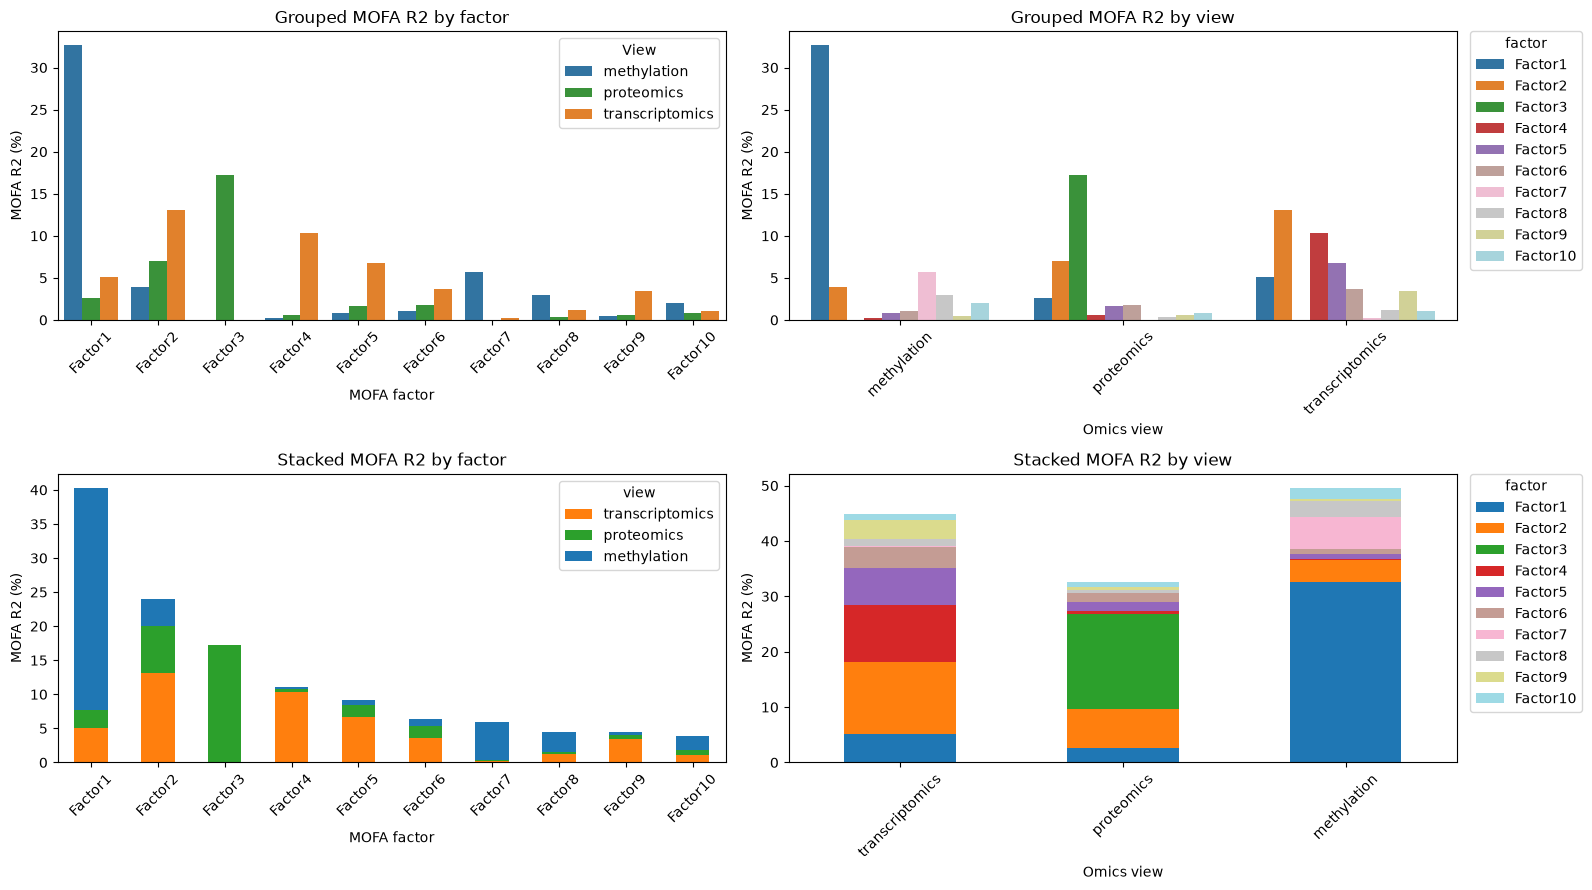

In [16]:
# Built-in mofax R2 barplots plus stacked summaries.
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Use fixed colors so the same view/factor has the same color across panels.
VIEW_COLORS = {
    "transcriptomics": "tab:orange",
    "proteomics": "tab:green",
    "methylation": "tab:blue",
}
view_palette = [VIEW_COLORS[view] for view in view_names]
factor_colors = plt.cm.tab20(np.linspace(0, 1, len(active_factor_cols)))

# Top left: grouped bars compare omics views within each factor.
mfx.plot_r2_barplot(
    mofa_model_mfx,
    factors=active_factor_indices,
    view=None,
    x="Factor",
    groupby="View",
    palette=VIEW_COLORS,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Grouped MOFA R2 by factor")
axes[0, 0].set_xlabel("MOFA factor")
axes[0, 0].set_ylabel("MOFA R2 (%)")
axes[0, 0].tick_params(axis="x", rotation=45)

# Top right: grouped bars compare factors within each omics view.
mfx.plot_r2_barplot(
    mofa_model_mfx,
    factors=active_factor_indices,
    view=None,
    x="View",
    groupby="Factor",
    palette=factor_colors,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Grouped MOFA R2 by view")
axes[0, 1].set_xlabel("Omics view")
axes[0, 1].set_ylabel("MOFA R2 (%)")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].legend(title="factor", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

# For stacked panels, use the same official mofax R2 table.
r2_for_bars = mofa_model_mfx.get_r2(factors=active_factor_indices, per_factor=True).copy()
r2_for_bars["factor"] = r2_for_bars["Factor"]

# Bottom left: each factor is one bar, stacked by omics view.
r2_stacked_by_factor = (
    r2_for_bars
    .pivot_table(index="factor", columns="View", values="R2", aggfunc="sum")
    .reindex(index=active_factor_cols, columns=view_names)
)
r2_stacked_by_factor.plot(kind="bar", stacked=True, ax=axes[1, 0], color=view_palette)
axes[1, 0].set_title("Stacked MOFA R2 by factor")
axes[1, 0].set_xlabel("MOFA factor")
axes[1, 0].set_ylabel("MOFA R2 (%)")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend(title="view")

# Bottom right: each view is one bar, stacked by factor.
r2_stacked_by_view = (
    r2_for_bars
    .pivot_table(index="View", columns="factor", values="R2", aggfunc="sum")
    .reindex(index=view_names, columns=active_factor_cols)
)
r2_stacked_by_view.plot(kind="bar", stacked=True, ax=axes[1, 1], color=factor_colors)
axes[1, 1].set_title("Stacked MOFA R2 by view")
axes[1, 1].set_xlabel("Omics view")
axes[1, 1].set_ylabel("MOFA R2 (%)")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend(title="factor", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()


**Discussion of the variance-explained barplots.**

These four panels show the same MOFA R2 information as the heatmap, but arranged in different ways. The goal here is not to introduce a new result; it is to practice reading the same variance-explained output through several plotting styles, including functions provided by `mofax`.

The top-left panel groups bars by factor, so it is easiest to ask: for each factor, which omics view contributes most? This again highlights `Factor1` as strongly methylation-driven, `Factor2` as more mixed across views, and `Factor3` as mainly proteomics-driven. The top-right panel flips the question and groups by omics view, making it easier to ask: within each view, which factors explain most of the variance?

The stacked plots summarize the same values more compactly. The stacked-by-factor plot emphasizes the total R2 carried by each factor and shows that `Factor1`, `Factor2`, and `Factor3` dominate overall. The stacked-by-view plot emphasizes the total reconstructed variance per omics layer and shows that methylation has the largest explained component in this fitted model, followed by transcriptomics and proteomics.

So the interpretation is consistent across panels: some factors are view-specific, while others capture signal across several views. In the workshop, showing the same R2 table in multiple formats is useful because each layout answers a slightly different visual question, and it also demonstrates which `mofax` plotting functions are available for inspecting MOFA models.


## 7. Inspect factor values (`Z`): project test patients and predict subtype 

After fitting MOFA on training patients, the next object we need is the **factor matrix**.

This matrix has:

- one row per patient,
- one column per latent factor,
- numeric entries called factor values.

A high positive or negative factor value means that the patient is strongly positioned along that hidden axis. The sign itself is arbitrary: multiplying a factor and its weights by `-1` would describe the same pattern. What matters is the relative position of patients and the features associated with each side of the factor.

These factor values are the integrated patient representation used for visualization and downstream subtype prediction. For test patients, we estimate factor values by projection, not by refitting MOFA.

How do we interpret the factor values?
Each factor captures a different source of variability in the data. Mathematically, each Factor is defined by a linear combination of the input features. As the data is centered prior to running MOFA, each Factor ordinates cells along a one-dimensional axis that is centered at zero. Samples with different signs manifest opposite phenotypes along the inferred axis of variation, with higher absolute value indicating a stronger effect. Note that the interpretation of MOFA factors is analogous to the interpretation of the principal components in PCA.



### 7.0 Project held-out test patients into the MOFA factor space

MOFA was fitted only on the training patients, so the test patients do not automatically have factor values from the fitted model. To evaluate the classifier on held-out patients, we need to **project** the test omics matrices into the factor space learned from the training data.

Projection means: keep the learned MOFA weights/loadings fixed, then estimate where each test patient falls on those same latent factors. The code below wraps this step in a small function so the workflow is explicit: training factors come from the fitted model, while test factors are estimated from the held-out omics matrices without refitting MOFA.


In [17]:
def project_test_patients_to_mofa_factors(model, X_train_by_view, X_test_by_view, train_factors, view_names):
    """Project held-out patients into the fixed MOFA factor space.

    The projection uses MOFA weights learned from training patients. To keep train and test factor
    values comparable, preprocessing and calibration are learned from training patients only.
    """
    factor_columns = train_factors.columns.astype(str).tolist()
    projected_test_by_view = []

    for view_name in view_names:
        # W is the learned feature x factor weight matrix for this omics view.
        weights = model.get_weights(views=view_name, df=True)
        weights.columns = weights.columns.astype(str)
        weights = weights.reindex(columns=factor_columns)

        # Use the features that exist in the trained weights and in both train/test matrices.
        common_features = weights.index.intersection(X_train_by_view[view_name].columns)
        common_features = common_features.intersection(X_test_by_view[view_name].columns)
        weights = weights.loc[common_features]

        X_train_view = X_train_by_view[view_name].loc[:, common_features].astype(float)
        X_test_view = X_test_by_view[view_name].loc[:, common_features].astype(float)
        X_train_view.index = X_train_view.index.astype(str)
        X_test_view.index = X_test_view.index.astype(str)

        # Learn centering/scaling on training patients only, then apply it to test patients.
        train_mean = X_train_view.mean(axis=0)
        train_std = X_train_view.std(axis=0, ddof=0).replace(0, 1)
        X_train_scaled = (X_train_view - train_mean) / train_std
        X_test_scaled = (X_test_view - train_mean) / train_std

        # Project X into the fixed MOFA weight space using a pseudo-inverse of W.
        raw_train_projection = X_train_scaled.to_numpy() @ np.linalg.pinv(weights.to_numpy()).T
        raw_test_projection = X_test_scaled.to_numpy() @ np.linalg.pinv(weights.to_numpy()).T

        # Calibrate the raw projection to the factor scale returned by the trained MOFA model.
        # This step is fitted on training patients only; test labels are never used.
        train_design = np.column_stack([raw_train_projection, np.ones(raw_train_projection.shape[0])])
        test_design = np.column_stack([raw_test_projection, np.ones(raw_test_projection.shape[0])])
        train_target = train_factors.loc[X_train_view.index, factor_columns].to_numpy()
        calibration = np.linalg.lstsq(train_design, train_target, rcond=None)[0]
        projected_values = test_design @ calibration

        projected = pd.DataFrame(projected_values, index=X_test_view.index, columns=factor_columns)
        projected_test_by_view.append(projected)

    # Each view gives one projected factor table. Average them because all views are available here.
    return sum(projected_test_by_view) / len(projected_test_by_view)


# Extract training-patient factor values from the training-fitted MOFA model.
train_factors_mfx = mofa_model_mfx.get_factors(df=True)
train_factors_mfx.index = train_factors_mfx.index.astype(str)

# Project held-out test patients into the factor space learned from training patients.
test_factors_mfx = project_test_patients_to_mofa_factors(
    mofa_model_mfx,
    X_train_omics,
    X_test_omics,
    train_factors_mfx,
    view_names,
)

# Combine training factors and projected test factors into one patient x factor table.
# Keep the native mofax factor names, such as Factor1, Factor2, and so on.
factors_df = pd.concat([train_factors_mfx, test_factors_mfx], axis=0)
factors_df.columns = factors_df.columns.astype(str)
factors_df = factors_df.reindex(patient_ids.astype(str))

# Keep all factor columns, then select the active factors identified from the R2 output.
all_factor_cols = factors_df.columns.tolist()
if "active_factor_cols" not in globals():
    active_factor_cols = all_factor_cols
feature_cols = [factor for factor in active_factor_cols if factor in all_factor_cols]
if not feature_cols:
    feature_cols = all_factor_cols

print(f"Using {len(feature_cols)} active MOFA factors downstream:", feature_cols)

# Add subtype labels only for interpretation/visualization/evaluation, not as MOFA input.
factors_df["subtype"] = y.reindex(factors_df.index).values
factors_df["split"] = "test"
factors_df.loc[train_ids.astype(str), "split"] = "train"

# Attach training sample metadata to the mofax model so built-in plotting functions can color by subtype.
# The model itself only contains training samples, which is what we want for factor interpretation.
mofa_sample_metadata = pd.DataFrame(index=train_factors_mfx.index)
mofa_sample_metadata["subtype"] = y_train.reindex(train_factors_mfx.index).values
mofa_sample_metadata["split"] = "train"
mofa_sample_metadata["subtype_train"] = mofa_sample_metadata["subtype"]
mofa_model_mfx.samples_metadata = mofa_sample_metadata

print("Training factor table:", train_factors_mfx.shape)
print("Projected test factor table:", test_factors_mfx.shape)
print("Combined factors_df:", factors_df.shape)

# Quick sanity check: projected test factors should now be on a comparable scale to training factors.
display(factors_df.groupby("split")[feature_cols].mean().style.format("{:.3f}"))
display(factors_df.groupby("split")[feature_cols].std().style.format("{:.3f}"))
display(factors_df.head())


Using 10 active MOFA factors downstream: ['Factor1', 'Factor2', 'Factor3', 'Factor4', 'Factor5', 'Factor6', 'Factor7', 'Factor8', 'Factor9', 'Factor10']
Training factor table: (375, 10)
Projected test factor table: (125, 10)
Combined factors_df: (500, 12)


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
split,,,,,,,,,,
test,0.121,-0.081,-0.034,0.126,-0.074,0.021,-0.052,0.077,0.013,-0.012
train,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
split,,,,,,,,,,
test,1.715,2.230,0.865,1.455,1.895,1.248,1.175,0.767,0.607,0.525
train,2.305,2.479,1.885,2.470,2.634,1.627,2.092,1.192,1.198,1.051


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,subtype,split
TCGA-AQ-A1H2,2.252545,1.925917,1.897713,-3.591158,-4.026937,0.898499,-3.093382,-1.705586,-0.766491,-1.835124,LumA,train
TCGA-A1-A0SF,1.411444,1.634321,0.354355,1.665056,2.111363,-0.515782,-0.313982,-1.585250,0.827522,0.188681,LumA,train
TCGA-AR-A255,0.800907,0.532262,-0.620395,1.122769,-0.256840,-0.672070,-0.599978,0.179573,-0.159658,-0.184427,LumA,test
TCGA-E2-A1BD,2.998781,1.546260,2.201322,-0.621823,-2.582888,-0.864503,2.465980,-0.960911,1.581886,1.240194,LumA,train
TCGA-A2-A0YI,0.279098,2.862159,0.771067,0.897244,2.972704,-0.317569,0.881563,0.824262,0.253077,-0.475051,LumA,train


### 7.1 Read the combined factor table

The factor table is the central object for prediction and interpretation. Training-patient factor values come directly from the fitted MOFA model; test-patient factor values are projected into that fixed factor space.

Each row is a patient. Each `FactorN` column, such as `Factor1`, is one learned axis of variation. The values are continuous and centered around zero. A patient with a large positive value and a patient with a large negative value are on opposite sides of that latent pattern.

Important details for interpretation:

- The factor order does not imply importance by itself. We rank factors using subtype association and view/weight summaries.
- The sign is arbitrary. If all values and weights for a factor were multiplied by `-1`, the model would describe the same pattern.
- A factor can be biologically meaningful even if it does not separate subtypes. It may capture immune infiltration, proliferation, batch effects, or another source of variation.


In [18]:
# Inspect the scale of the factor values.
factor_summary = factors_df[feature_cols].describe()

# Format the table with regular decimal numbers instead of scientific notation.
display(factor_summary.style.format("{:.3f}"))


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,0.030,-0.020,-0.008,0.032,-0.019,0.005,-0.013,0.019,0.003,-0.003
std,2.172,2.417,1.688,2.259,2.468,1.540,1.903,1.101,1.081,0.947
min,-4.377,-7.733,-6.779,-4.409,-7.569,-5.250,-7.001,-3.363,-6.252,-4.309
25%,-1.742,-1.522,-0.760,-1.474,-1.502,-0.844,-1.232,-0.717,-0.600,-0.558
50%,0.141,0.636,0.299,-0.298,-0.226,0.002,0.316,0.042,-0.022,-0.053
75%,1.670,1.759,1.156,1.244,1.485,1.047,1.340,0.733,0.683,0.536
max,5.045,4.145,2.937,7.830,6.410,4.131,4.721,3.615,3.061,3.097


This table summarizes the scale of the MOFA factors. Factor values are usually centered around zero, but different factors can have different spreads. This means that a value such as `2` should be interpreted relative to the distribution of the same factor, not as an absolute score shared across all factors.

A wider factor distribution does not automatically mean that the factor is more biologically important. Factor importance should be assessed by combining several diagnostics: variance explained, subtype association, view contributions, and feature weights/loadings.


### 7.2 Predict subtype from factor values (`Z`)

This section asks this question: do the unsupervised MOFA factors contain subtype-relevant information?

We train a simple classifier using only the learned factor values. The original high-dimensional omics features are NOT passed to this classifier. This makes the evaluation about the quality of the MOFA representation, not about the raw feature space.

The prediction model sees a table like `patients x 10 MOFA factors`, and tries to predict one subtype label per patient.

Interpretation guide:

- Good performance suggests that subtype structure is present in the latent factors.
- Poor performance does not mean MOFA failed; the strongest unsupervised variation may reflect processes other than subtype.
- The classifier is evaluated only on held-out patients, so the reported metrics are not training-set accuracy.


,model,accuracy,balanced_accuracy,macro_f1
0,MOFA factors + logistic regression,0.784,0.817667,0.755148


              precision    recall  f1-score   support

       Basal       1.00      0.96      0.98        24
        Her2       0.88      0.70      0.78        10
        LumA       0.90      0.75      0.82        60
        LumB       0.59      0.68      0.63        25
      Normal       0.40      1.00      0.57         6

    accuracy                           0.78       125
   macro avg       0.75      0.82      0.76       125
weighted avg       0.83      0.78      0.80       125



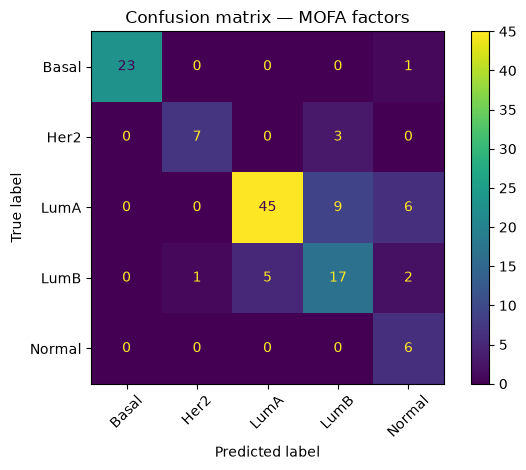

In [19]:
# Train logistic regression on training patients and predict held-out patients.
# The classifier receives training MOFA factor values and projected test factor values, not the original omics matrices or weights.
mofa_factor_clf, mofa_pred, mofa_metrics = fit_factor_classifier(
    factors_df[feature_cols],
    y,
    train_ids.astype(str),
    test_ids.astype(str),
    "MOFA factors + logistic regression",
)

# Store metrics in a table so this result can be compared with later models.
results_df = pd.DataFrame([mofa_metrics]).sort_values("balanced_accuracy", ascending=False)
display(results_df)

# Show per-subtype precision, recall, and F1 on the held-out test set.
print(classification_report(y_test, mofa_pred))

# Visualize which subtypes are confused with each other.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    mofa_pred,
    xticks_rotation=45,
)
plt.title("Confusion matrix — MOFA factors")
plt.tight_layout()
plt.show()


**Conclusion from this prediction step.**

This prediction step asks whether the MOFA factor values learned from the training patients contain enough subtype information to classify held-out patients. Here the result is reasonably strong for a simple logistic regression on only `10` MOFA factors: accuracy is about `0.78`, balanced accuracy is about `0.82`, and macro-F1 is about `0.76`. Balanced accuracy is especially useful here because the subtype classes are imbalanced.

The classification report shows that `Basal` is predicted very well, with high precision and recall. `LumA` is also captured fairly well, although some LumA patients are confused with `LumB` or `Normal`. `LumB` is more difficult: recall is moderate and several LumB patients are predicted as `LumA`, which is biologically plausible because these luminal subtypes are related and can be harder to separate. `Her2` has good precision but lower recall, meaning the model is fairly reliable when it predicts Her2, but misses some Her2 patients. `Normal` has perfect recall in this test set, but its precision is lower because several non-Normal samples are also predicted as Normal; this should be interpreted cautiously because there are only `6` Normal samples in the test set.

The confusion matrix makes the same pattern easier to see. Most Basal samples are correctly classified (`23/24`), all Normal samples are classified as Normal (`6/6`), and the largest errors occur among the luminal-related groups: LumA is sometimes predicted as LumB or Normal, and LumB is sometimes predicted as LumA. Overall, this suggests that the MOFA factor representation preserves meaningful subtype structure, but the subtype separation is not perfect, especially for related or small classes.


### 7.3 Quantify which factors are associated with subtype

Before choosing which factor plots to focus on, we quantify the subtype association for each factor using the training patients.

MOFA factors are not named by the model. They come out as `Factor1`, `Factor2`, and so on. We need post hoc diagnostics to decide which factors are biologically interesting.

Here we use an ANOVA-style summary called **eta-squared**. The idea is to ask, for each MOFA factor: do patients from different subtypes tend to have different factor values?

A one-way ANOVA compares the variation **between subtype groups** with the variation **within subtype groups**. If the subtype groups have very similar factor-value distributions, then subtype explains little of that factor. If the subtype groups have clearly different factor values, then subtype explains more of that factor.

Eta-squared turns this into a simple proportion: it estimates the fraction of a factor's total variation that can be attributed to subtype group differences. For example, an eta-squared value near `0` means subtype explains almost none of the factor variation, while a larger value means the factor is more subtype-associated.

Interpretation guide:

- Larger eta-squared means factor values differ more strongly across subtypes.
- A factor with high eta-squared is a good candidate for subtype-associated biology.
- This is an association score, not proof that the factor is causally related to subtype.


In [20]:
def eta_squared_by_factor(factor_table, labels):
    """Compute one-way ANOVA eta-squared for each factor without fitting a predictive model."""
    # eta-squared measures the fraction of factor variance explained by subtype groups.
    rows = []
    labels = labels.astype(str)

    for factor in factor_table.columns:
        values = factor_table[factor]
        grand_mean = values.mean()
        ss_total = ((values - grand_mean) ** 2).sum()
        ss_between = 0.0

        for subtype, idx in labels.groupby(labels).groups.items():
            group_values = values.loc[idx]
            ss_between += len(group_values) * (group_values.mean() - grand_mean) ** 2

        eta2 = ss_between / ss_total if ss_total > 0 else np.nan
        rows.append({"factor": factor, "eta_squared": eta2})

    return pd.DataFrame(rows).sort_values("eta_squared", ascending=False)


# Rank factor-subtype associations using training patients only.
factor_subtype_assoc = eta_squared_by_factor(
    factors_df.loc[train_ids.astype(str), feature_cols],
    y_train,
)

# Keep the most subtype-associated factors for the plots below.
top_factors = factor_subtype_assoc.head(10)["factor"].tolist()

# mofax uses Factor1/Factor2 labels and zero-based factor indices in many plotting functions.
top_factor_numbers = [int("".join(ch for ch in factor if ch.isdigit())) for factor in top_factors]
top_factors_mfx = top_factors
top_factor_indices = [number - 1 for number in top_factor_numbers]

display(factor_subtype_assoc)


,factor,eta_squared
1,Factor2,0.730277
0,Factor1,0.387930
5,Factor6,0.361851
3,Factor4,0.179090
8,Factor9,0.131847
9,Factor10,0.073170
7,Factor8,0.069703
4,Factor5,0.068817
2,Factor3,0.045278
6,Factor7,0.018829


**Discussion of the eta-squared results.**

This table ranks factors by how strongly their training-patient factor values differ across subtypes. Here, `Factor2` is clearly the most subtype-associated factor, with eta-squared around `0.73`. This means that a large fraction of the variation in `Factor2` values can be explained by subtype group differences.

The next strongest factors are `Factor1` and `Factor6`, with eta-squared values around `0.39` and `0.36`. These are also strong candidates for subtype-associated structure, but they are less dominant than `Factor2`. After that, the association drops: `Factor4` and `Factor9` show moderate subtype association, while `Factor10`, `Factor8`, `Factor5`, `Factor3`, and especially `Factor7` are weaker by this criterion.

This ranking is useful for deciding which patient-level factor plots to inspect first. However, eta-squared is not the same thing as MOFA R2. R2 asks how much molecular variance a factor reconstructs in each omics view, while eta-squared asks whether patients from different subtypes have different factor values. A factor can explain a lot of molecular variance without being strongly subtype-associated, and a lower-R2 factor can still be useful if it separates subtypes.

So in the next plots, we focus first on the high eta-squared factors because they are the most directly linked to subtype differences in the training set.


### 7.4 Visualize top subtype-associated factor values (`Z`)

Now that we have ranked the factors by subtype association, we visualize the most subtype-associated factors using **training patients only**. This keeps the interpretation consistent with the eta-squared ranking, which was also computed on the training set.

These plots use the same patient-level matrix `Z`, but they show it in different ways: scatter grids show individual patients, boxplots summarize factor values by subtype, and the heatmap summarizes mean factor activity across subtypes.


`mofax` plotting functions can use sample metadata stored in `mofa_model_mfx.samples_metadata`. We added subtype and train/test split metadata above, so the plots below can focus on training patients while still using the standard `mofax` factor plotting API.


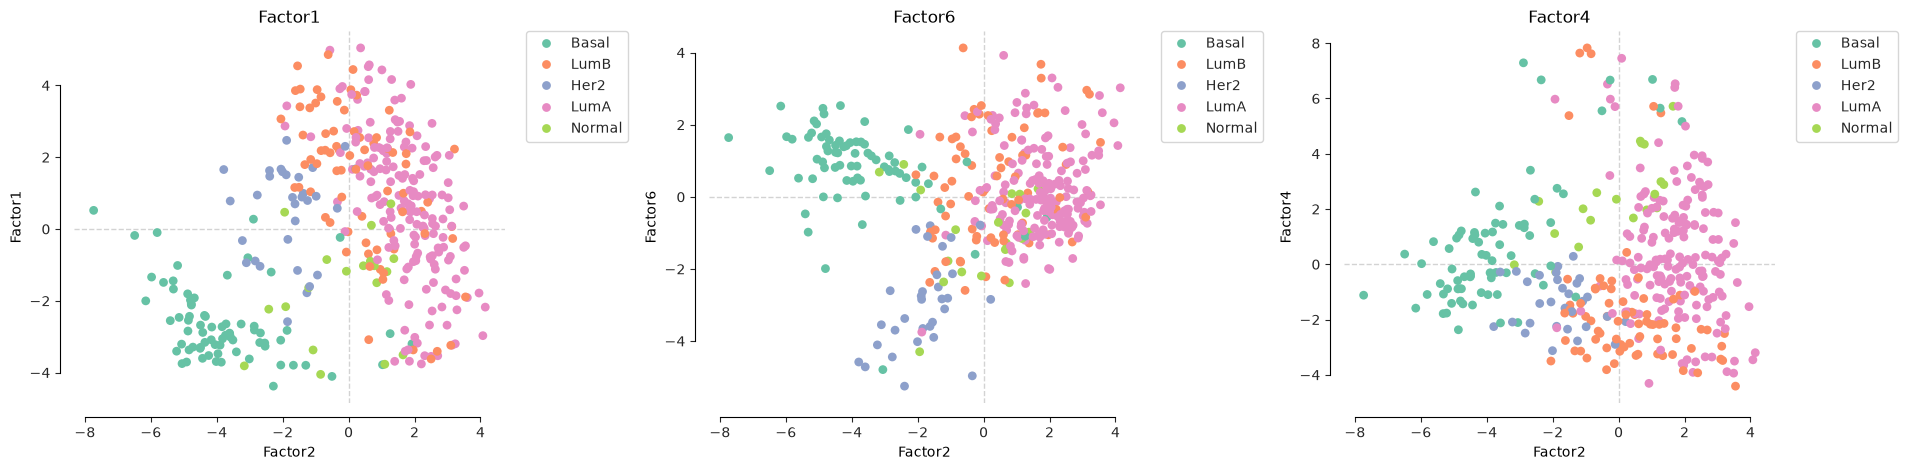

In [21]:
# Built-in mofax scatter grid for training patients.
# group_label="split", groups=["train"] filters to training patients;
# color="subtype" colors those patients by subtype.
mfx.plot_factors_scatter(
    mofa_model_mfx,
    x=top_factors_mfx[0],
    y=top_factors_mfx[1:4],
    group_label="split",
    groups=["train"],
    color="subtype",
    zero_line_x=True,
    zero_line_y=True,
    ncols=3,
    size=40,
    alpha=1,
)
plt.show()

**Discussion of the scatter grid.**

This grid uses `Factor2`, the most subtype-associated factor from the eta-squared ranking, as the common x-axis. Each panel then compares `Factor2` with another highly ranked factor: `Factor1`, `Factor6`, and `Factor4`. Each point is a training patient, colored by subtype.

The main pattern is that `Factor2` separates a large part of the subtype structure horizontally. Basal samples are mostly shifted toward low `Factor2` values, while LumA samples are mostly shifted toward higher `Factor2` values. This is consistent with `Factor2` having the highest eta-squared value in the previous table.

The y-axis factors add complementary information. In the `Factor1` panel, Basal samples tend to have lower `Factor1` values, whereas many LumA and LumB samples sit higher or closer to the center. In the `Factor6` panel, Her2 samples appear more clearly separated toward lower `Factor6` values, while LumA samples are more concentrated around positive or near-zero values. In the `Factor4` panel, Basal samples are again separated from many luminal samples, but there is also substantial overlap.

Overall, no single factor perfectly separates all subtypes. Instead, subtype structure is distributed across several MOFA factors. This is exactly why the scatter grid is useful: it shows how combinations of factor values create subtype separation, while also revealing overlap between related groups such as LumA and LumB.


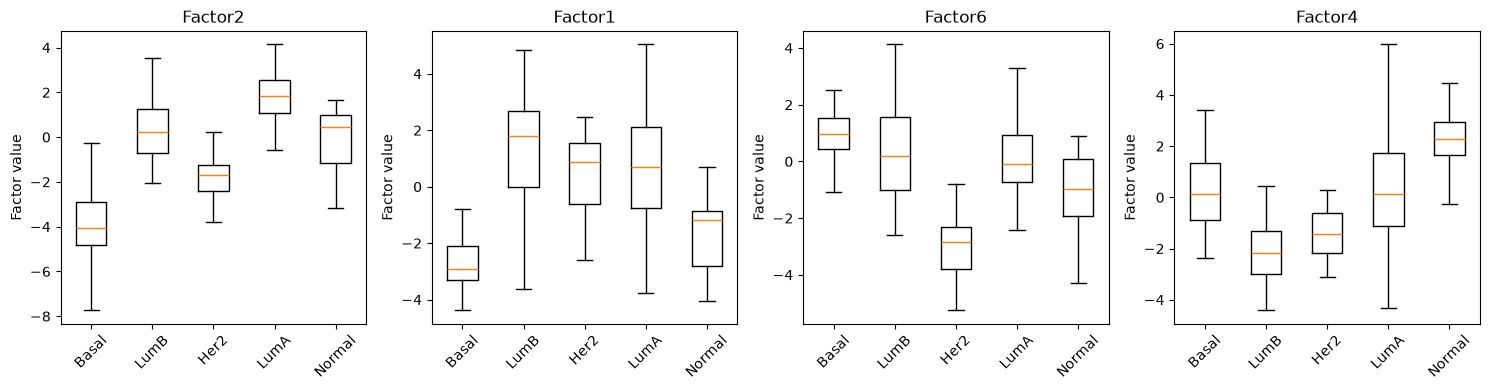

In [23]:
train_factors_for_plot = factors_df.loc[train_ids.astype(str), feature_cols]
train_labels_for_plot = y_train.astype(str)

# Summarize the top factor values by subtype with simple boxplots.
fig, axes = plt.subplots(1, 4, figsize=(15, 4), squeeze=False)
subtypes = train_labels_for_plot.dropna().unique()

for ax, factor in zip(axes.ravel(), top_factors[:4]):
    groups = [
        train_factors_for_plot.loc[train_labels_for_plot == subtype, factor].dropna()
        for subtype in subtypes
    ]
    ax.boxplot(groups, tick_labels=subtypes, showfliers=False)
    ax.set_title(factor)
    ax.set_ylabel("Factor value")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**Discussion of the boxplots.**

These boxplots summarize the same training-patient factor values by subtype. Compared with the scatter grid, they make it easier to see which subtype groups have shifted factor-value distributions.

`Factor2` shows the clearest subtype separation, which matches its high eta-squared score. Basal samples have strongly negative `Factor2` values, LumA samples have clearly positive values, and LumB samples sit closer to the center. Her2 is also shifted negative, while Normal samples are more variable. This suggests that `Factor2` captures a major subtype-associated axis.

`Factor1` also separates Basal from several other groups: Basal samples are mostly negative, whereas LumB, Her2, and LumA tend to be higher. `Factor6` is especially useful for Her2, which has lower values than the other subtypes. `Factor4` highlights a different contrast, with LumB and Her2 tending lower and Normal tending higher, although there is overlap between groups.

The important point is that subtype information is not carried by one factor alone. `Factor2` is the strongest single axis, but `Factor1`, `Factor6`, and `Factor4` each add different subtype contrasts. This explains why the classifier can use the full factor table rather than relying on only the top-ranked factor.


#### 7.4.1 Mean factor activity by subtype

A factor's **activity** in a patient is its factor value. By averaging factor values within each subtype, we can see whether a factor is high in one subtype and low in another.

This is often easier to read than a scatter plot when there are several factors. We select the factors using the eta-squared ranking from Section 7.3. `mofax` may display them in factor-label order, so read the row labels directly rather than assuming the first row is always the top-ranked factor.


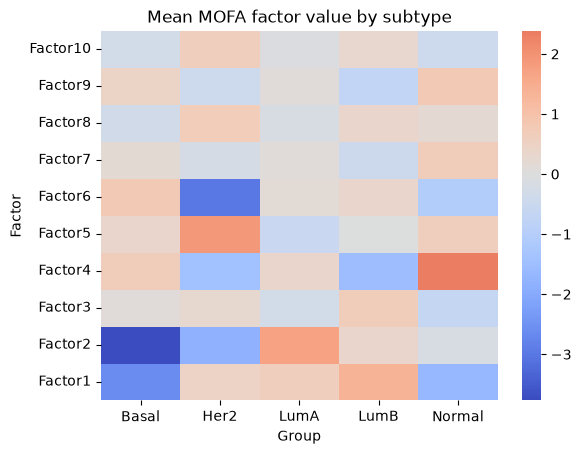

In [24]:
# Built-in mofax heatmap of mean factor value by subtype, using training patients only.
# subtype_train is NaN for test patients, so only training patients contribute to these subtype means.
mfx.plot_factors_matrix(
    mofa_model_mfx,
    factors=top_factor_indices,
    group_label="subtype_train",
    cmap="coolwarm",
    center=0,
)
plt.title("Mean MOFA factor value by subtype")
plt.show()


**Discussion of the factor activity heatmap.**

This heatmap provides a compact summary of the factor-value patterns explored in the scatter plots and boxplots. Rather than adding a completely new analysis, it gives a complementary overview: many factors and subtypes can be compared at once, and it also illustrates another useful `mofax` plotting function for factor interpretation.

Each cell is the mean training-patient factor value for one subtype. Red means that the subtype has a higher average value on that factor, while blue means a lower average value. The sign itself is arbitrary in MOFA, so the important part is the contrast between subtypes, not whether a subtype is red or blue in an absolute biological sense.

The strongest pattern is again visible for `Factor2`: Basal is strongly negative, while LumA is positive, matching the eta-squared ranking and the boxplots. `Factor1` also separates Basal from several other groups, with Basal shifted negative and LumB/LumA shifted higher. `Factor6` highlights Her2 as strongly negative compared with the other subtypes, and `Factor4` shows a strong positive average for Normal with lower values in LumB and Her2.

Overall, this heatmap reinforces the same conclusion as the previous plots: subtype-associated structure is distributed across several MOFA factors. The advantage of this view is that it gives a quick overview of factor-by-subtype patterns, while the scatter and boxplots show the underlying patient-level spread.


## 8. Inspect weights/loadings (`W`): which features define the factors?

This section uses the **MOFA weights/loadings**: the feature-by-factor matrices that tell us which genes, proteins, or methylation probes define each factor.

For each factor and each omics view, MOFA learns one weight per feature. A feature with a large absolute weight contributes strongly to that factor. The sign of a weight tells us the direction of contribution relative to the factor value.

In this section we first summarize weights at the view level. This answers a broad question: is a factor mostly driven by transcriptomics, proteomics, methylation, or a combination of views?

Later, we inspect individual top-weighted features to make the interpretation more concrete.

*To keep the workshop code reusable, we use built-in `mofax` plotting functions directly.*


In [25]:
# mofax gives one feature x factor weight table per view.
# Here we summarize the mean absolute weight for each factor/view combination.
rows = []
for view_name in view_names:
    weights = mofa_model_mfx.get_weights(views=view_name, df=True)
    for factor in feature_cols:
        factor_number = int("".join(ch for ch in factor if ch.isdigit()))
        rows.append(
            {
                "view": view_name,
                "factor": factor,
                "mean_abs_weight": weights[f"Factor{factor_number}"].abs().mean(),
            }
        )

view_weight_summary = pd.DataFrame(rows)
view_weight_pivot = view_weight_summary.pivot(
    index="factor",
    columns="view",
    values="mean_abs_weight",
)

display(view_weight_pivot)


view,methylation,proteomics,transcriptomics
factor,,,
Factor1,0.236850,0.023597,0.052293
Factor10,0.101093,0.050994,0.055302
Factor2,0.074885,0.053670,0.103283
Factor3,0.000002,0.161036,0.001885
Factor4,0.006243,0.010721,0.092641
Factor5,0.016957,0.017759,0.041903
Factor6,0.040112,0.038922,0.076657
Factor7,0.067354,0.000072,0.007738
Factor8,0.101788,0.019067,0.055995


**Discussion of the view-level weight summary.**

This table summarizes the average absolute MOFA weight for each factor and each omics view. It asks a different question from R2: R2 tells us how much variance a factor explains in a view, while these mean absolute weights tell us how strongly, on average, the features in that view contribute to the factor.

The largest value is for `Factor1` in methylation, which suggests that `Factor1` is strongly defined by methylation loadings. `Factor3` stands out in proteomics, consistent with the R2 plots where this factor was mainly proteomics-driven. Transcriptomics has relatively strong average weights for `Factor9`, `Factor2`, and `Factor4`, suggesting that these factors are more strongly shaped by gene-expression features.

Some factors show contributions across several views. For example, `Factor2` has non-negligible weights in transcriptomics, methylation, and proteomics, which supports the idea that it captures a more multi-view signal. Other factors are more view-specific, such as `Factor7`, which is mostly methylation-weighted in this summary.

These values should be interpreted as a broad view-level diagnostic, not as a final biological explanation. A high mean absolute weight tells us which omics layer contributes to defining a factor, but the next step is to inspect the top individual features to understand what molecular signals are driving that contribution.


### 8.1 Top feature loadings

The view-level summary tells us which omics layers contribute to a factor, but not which molecules drive the signal. To interpret a factor biologically, we inspect the strongest feature weights, also called **loadings**.

For each selected factor and view, we rank features by absolute weight and show the top 5 per factor per view.

Interpretation guide:

- Large absolute weights identify features that define the factor.
- Positive and negative weights mark opposite sides of the same latent axis.
- Top features should be interpreted together, not one at a time, because a factor represents a coordinated pattern of variation.


In [26]:
# mofax can directly return the strongest feature weights for selected factors and views.
# Create the gene-symbol map if this cell is rerun without rerunning the setup cell first.
if "gene_symbol_map" not in globals():
    gene_symbol_table = pd.read_csv(GENE_SYMBOL_MAP_FILE)
    gene_symbol_map = dict(zip(gene_symbol_table["ensembl_gene_id"], gene_symbol_table["symbol"]))

top_loading_features = mofa_model_mfx.get_top_features(
    factors=top_factor_indices,
    views=view_names,
    n_features=10,
    absolute_values=False,
    per_view=True,
    df=True,
)

top_loading_features = top_loading_features.rename(
    columns={
        "feature": "feature_id",
        "factor": "factor_mofax",
        "value": "weight",
        "value_abs": "abs_weight",
    }
)
top_loading_features["factor"] = top_loading_features["factor_mofax"]

# Keep readable gene symbols for transcriptomics while preserving the original feature IDs.
feature_labels = top_loading_features["feature_id"].astype(str)
ensembl_without_version = feature_labels.str.replace(r"\..*$", "", regex=True)
top_loading_features["feature"] = np.where(
    top_loading_features["view"].eq("transcriptomics"),
    ensembl_without_version.map(gene_symbol_map).fillna(feature_labels),
    feature_labels,
)

top_loading_features["rank"] = (
    top_loading_features
    .sort_values(["factor", "view", "abs_weight"], ascending=[True, True, False])
    .groupby(["factor", "view"])
    .cumcount()
    .add(1)
)

top_loading_features = top_loading_features[
    ["view", "factor", "rank", "feature", "feature_id", "weight", "abs_weight"]
].sort_values(["factor", "view", "rank"])

# Show a balanced preview: top 3 features for each selected factor and each view.
top_loading_preview = top_loading_features.groupby(["factor", "view"], group_keys=False).head(3)
display(top_loading_preview)


,view,factor,rank,feature,feature_id,weight,abs_weight
270,methylation,Factor1,1,cg01893212,cg01893212,0.449030,0.449030
271,methylation,Factor1,2,cg20399616,cg20399616,0.426160,0.426160
272,methylation,Factor1,3,cg02467990,cg02467990,0.425058,0.425058
275,proteomics,Factor1,1,ERALPHA,ERALPHA,0.412731,0.412731
281,proteomics,Factor1,2,GATA3,GATA3,0.313809,0.313809
...,...,...,...,...,...,...,...
21,proteomics,Factor9,2,VAV1,VAV1,-0.127763,0.127763
22,proteomics,Factor9,3,CKIT,CKIT,0.123232,0.123232
0,transcriptomics,Factor9,1,ENSG00000186847.6,ENSG00000186847.6,0.685468,0.685468
1,transcriptomics,Factor9,2,ENSG00000128422.17,ENSG00000128422.17,0.618415,0.618415


**Discussion of the top-loading feature table.**

This table shows individual features with the largest absolute weights for each selected factor and each omics view. The `feature` column shows gene symbols for transcriptomics features when a symbol is available, while `feature_id` keeps the original Ensembl identifier. For methylation and proteomics, the original feature names are kept.


### 8.3 Ranked and view-specific weight plots

We use transcriptomics as a concrete feature-level example.

Weight plots help answer: **what molecular features define this factor?**

A factor can be interpreted by looking at features with the largest absolute weights. In a signed plot, features on opposite sides of zero contribute in opposite directions. For example, patients with high factor values tend to be associated with features that have positive weights, while patients with low factor values tend to be associated with features that have negative weights.

The exact biological interpretation depends on the feature names and omics view.


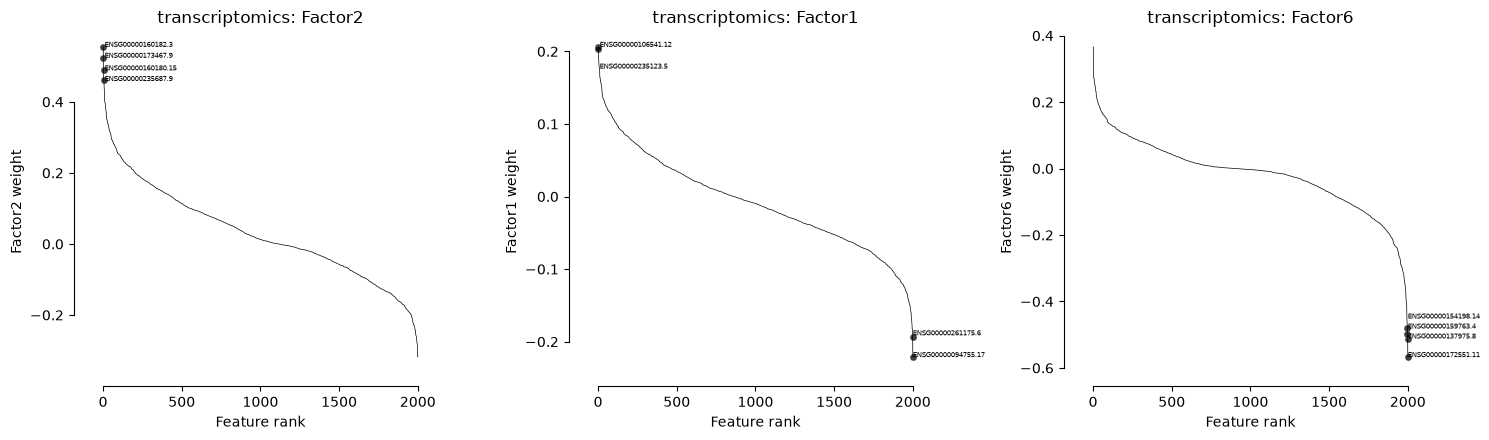

In [27]:
# Built-in mofax ranked-weight plots for three example factors and one view.
# Ranking very large views repeatedly can be slow, so we keep this focused on transcriptomics.
ranked_view = "transcriptomics"
ranked_factors = top_factors_mfx[:3]

fig, axes = plt.subplots(1, len(ranked_factors), figsize=(5 * len(ranked_factors), 4.5), squeeze=False)

for ax, ranked_factor in zip(axes.ravel(), ranked_factors):
    mfx.plot_weights_ranked(
        mofa_model_mfx,
        factor=ranked_factor,
        view=ranked_view,
        n_features=5,
        ax=ax,
    )
    ax.set_title(f"{ranked_view}: {ranked_factor}")

plt.tight_layout()
plt.show()


**Discussion of the ranked weight plots.**

These plots are focused examples of `mofax.plot_weights_ranked`. Each panel ranks transcriptomic features for one selected factor by their signed MOFA weight. Features at the positive and negative extremes are the strongest loadings for that factor, while features near zero contribute little to that factor.

Here we show the first three subtype-associated factors from the eta-squared ranking: `Factor2`, `Factor1`, and `Factor6`. The curves show that most transcriptomic features have weights close to zero, while a smaller number of genes sit at the tails and define the factor more strongly. This is useful because factor interpretation should focus on the tail features, not on the thousands of genes with tiny weights.

`Factor2` has a strong positive transcriptomic tail, meaning several genes contribute strongly to the positive side of this factor. `Factor1` has both positive and negative extremes, so genes at opposite ends may represent opposite sides of the same latent axis. `Factor6` shows a pronounced negative tail, suggesting that its transcriptomic signal is driven especially by genes with strong negative weights.

We show three factors rather than all factors because ranking large views repeatedly can take time. For teaching, the main lesson is the reusable workflow: choose a factor, choose a view, and inspect the strongest positive and negative loadings.


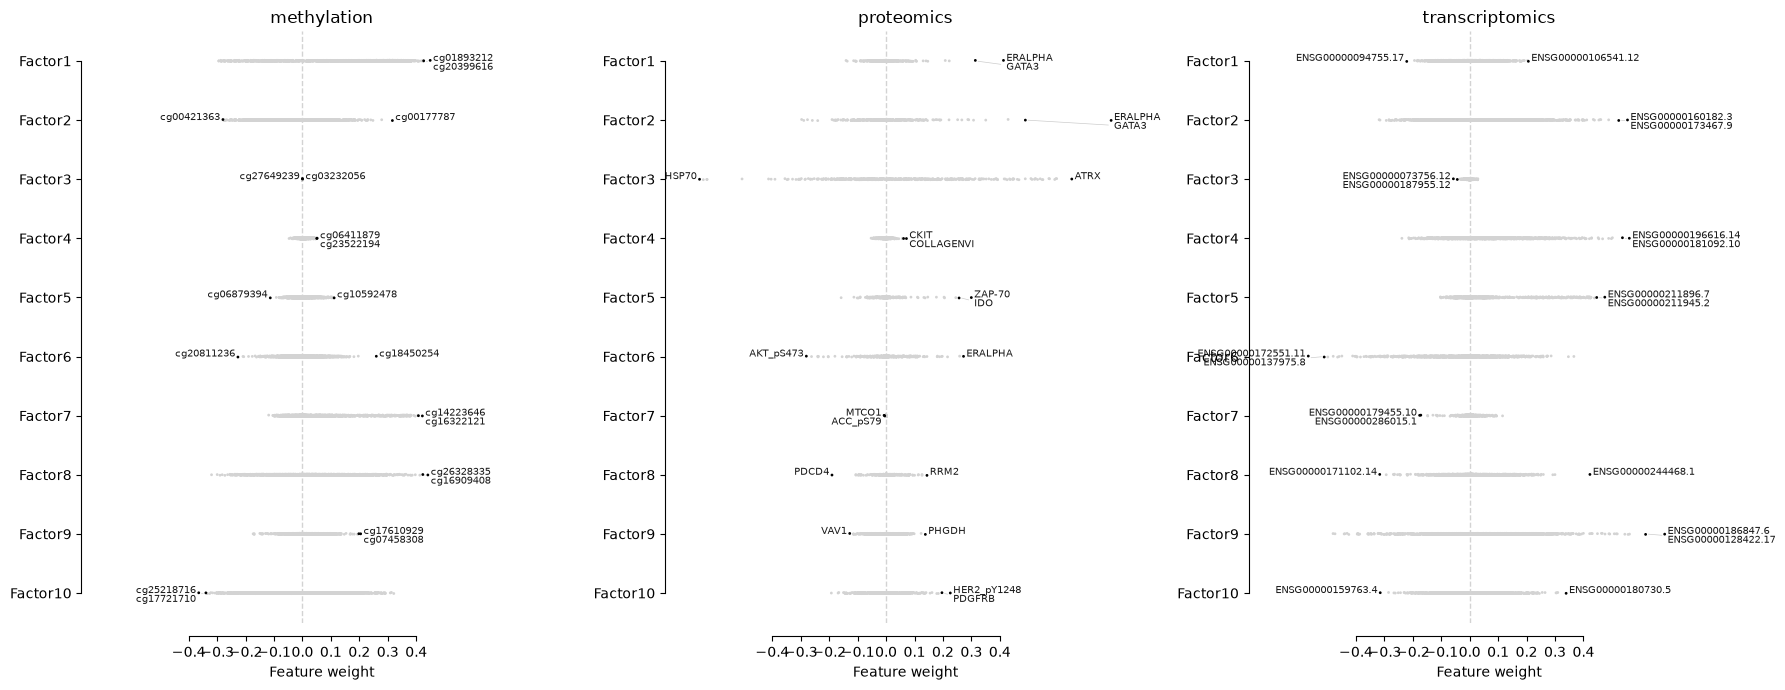

In [28]:
# Built-in mofax strip-style weight plot across all omics views.
# `mofax.plot_weights` creates one panel per view and uses its own matplotlib figure.
# Use rc_context to temporarily make each panel taller.
with plt.rc_context({"figure.figsize": (6, 7)}):
    mfx.plot_weights(
        mofa_model_mfx,
        factors=top_factor_indices,
        n_features=2,
        ncols=3,
        label_size=7,
    )
    plt.tight_layout()
    plt.show()


**Discussion of the multi-view weight overview.**

This plot uses `mofax.plot_weights` to show feature-weight distributions across the three omics views: methylation, proteomics, and transcriptomics. Each panel corresponds to one view. Within a panel, each row is a MOFA factor, grey points are feature weights, and the labelled points mark the strongest features for that factor in that view.

This figure complements the view-level weight table above. The table summarizes average absolute weights per view, while this plot shows the full distribution of signed feature weights. It therefore helps us see whether a factor is defined by a few extreme features, by many moderate features, or by very little signal in a given view.

The three panels also make view-specific interpretation more concrete. For example, methylation shows strong labelled probes for factors such as `Factor1`, proteomics highlights proteins such as `ERALPHA`, `GATA3`, or `ATRX` for specific factors, and transcriptomics highlights genes at the positive or negative tails. Features on opposite sides of zero contribute in opposite directions to the same factor.


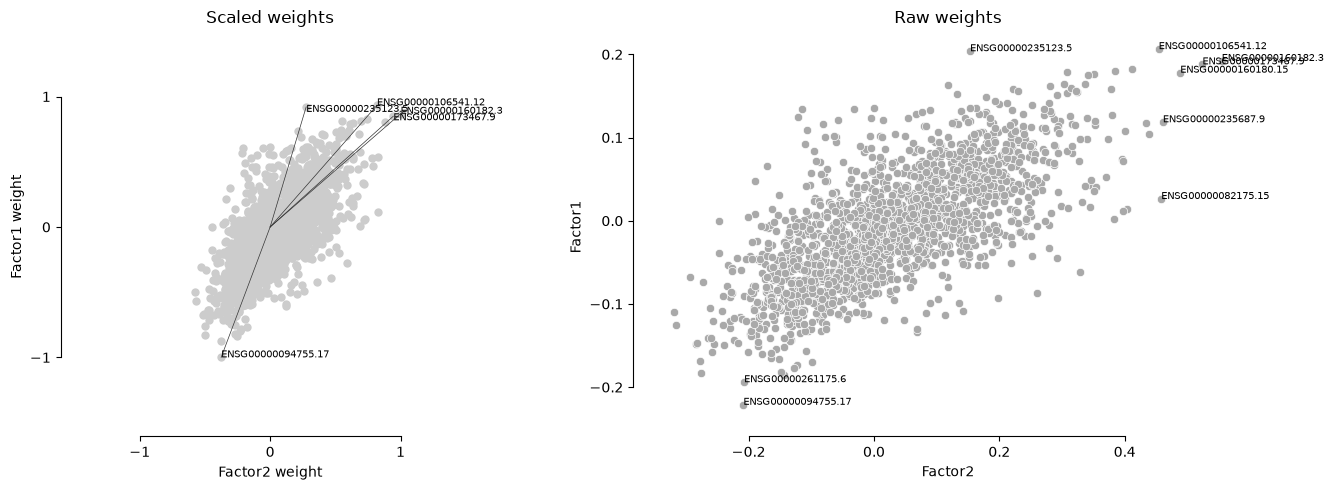

In [29]:
main_view = "transcriptomics"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mfx.plot_weights_scaled(
    mofa_model_mfx,
    x=top_factors_mfx[0],
    y=top_factors_mfx[1],
    view=main_view,
    n_features=5,
    label_size=7,
    ax=axes[0],
)
axes[0].set_title("Scaled weights")

mfx.plot_weights_scatter(
    mofa_model_mfx,
    x=top_factors_mfx[0],
    y=top_factors_mfx[1],
    view=main_view,
    hist=False,
    n_features=5,
    label_size=7,
    ax=axes[1],
)
axes[1].set_title("Raw weights")

plt.tight_layout()
plt.show()


**Discussion of the loading scatter plots.**

These plots compare transcriptomic feature weights for two subtype-associated factors, here `Factor2` on the x-axis and `Factor1` on the y-axis. Each point is a gene. Genes near the center have small weights for both factors, while labelled genes are outliers that strongly contribute to at least one of the two factors.

We show two versions because they answer slightly different questions. The **scaled weights** plot rescales the axes so the overall pattern is easier to compare visually. The **raw weights** plot keeps the original MOFA weight scale, which is better for seeing the actual magnitude and sign of the weights.

In both panels, many genes follow a diagonal positive trend: genes with positive `Factor2` weights often also have positive `Factor1` weights, and genes with negative `Factor2` weights often also have negative `Factor1` weights. This suggests that the transcriptomic parts of `Factor2` and `Factor1` share some structure rather than being completely independent gene signatures.

The labelled genes at the extremes are the most useful starting points for interpretation. Some genes contribute strongly to both factors, while others are more specific to one axis.


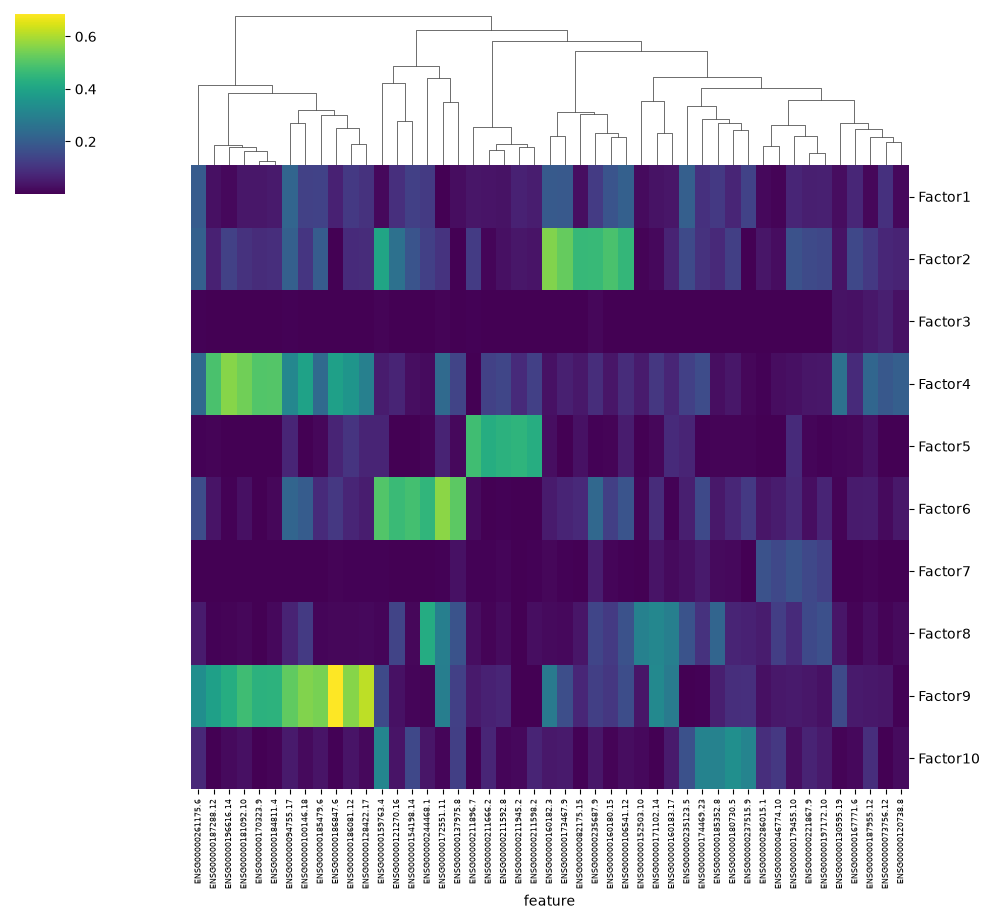

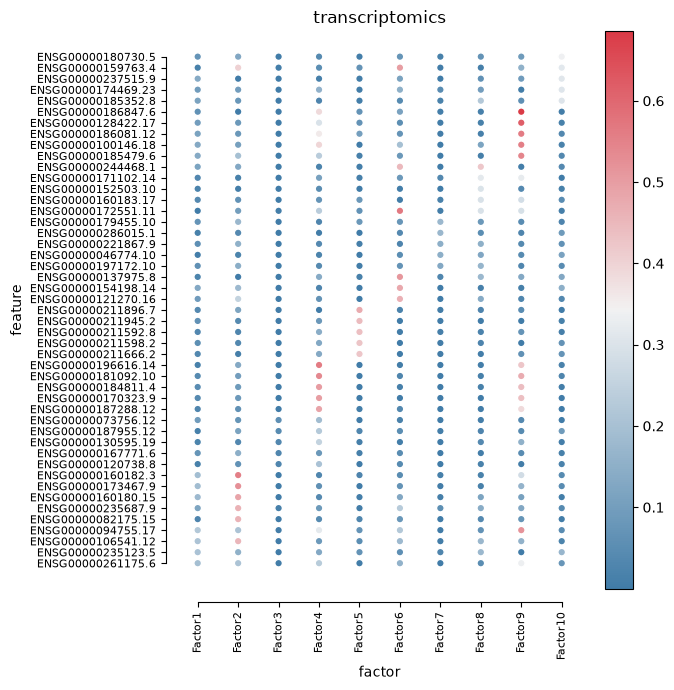

In [30]:
# Built-in mofax transcriptomics top-feature heatmap and dotplot.
# We focus on one view to avoid mixing genes, proteins, and methylation probes in the same feature-level plot.
# Note: these mofax functions create their own figures, so they cannot be placed inside plt.subplots axes.
heatmap_view = "transcriptomics"

mfx.plot_weights_heatmap(
    mofa_model_mfx,
    factors=top_factor_indices,
    view=heatmap_view,
    n_features=5,
    w_abs=True,
    cmap="viridis",
    xticklabels_size=6,
    cluster_factors=False,
    cluster_features=True,
)
plt.show()

with plt.rc_context({"figure.figsize": (7, 7)}):
    mfx.plot_weights_dotplot(
        mofa_model_mfx,
        factors=top_factor_indices,
        view=heatmap_view,
        n_features=5,
        w_abs=True,
        xticklabels_size=8,
        yticklabels_size=8,
    )
    plt.tight_layout()
    plt.show()


**Discussion of the transcriptomics weight heatmap and dotplot.**

These two figures inspect the same object: transcriptomics feature weights from the MOFA weight matrix (`W`). They are not meant to introduce a new analysis. The goal is to try different `mofax` plotting functions and see how the same top-feature information can be displayed in complementary ways.

Both plots focus on transcriptomics only. This keeps the feature-level interpretation cleaner, because genes, proteins, and methylation probes are not mixed in the same panel. For each selected factor, `mofax` selects the strongest transcriptomic features by absolute weight, so the displayed features are a compact subset of the transcriptome rather than all genes.

The heatmap is useful for seeing blocks of features that have high absolute weights for the same factor or for related factors. The dendrogram clusters features with similar weight profiles, which can help identify groups of genes that behave similarly across factors. The dotplot shows the same kind of information in a more compact factor-by-feature layout: larger/darker points indicate stronger absolute weights.

Because these plots use `w_abs=True`, they show the **strength** of a feature's contribution, not its direction. A strong value means the gene contributes strongly to that factor, but it does not tell us whether the signed weight is positive or negative. For direction, we need to go back to the signed ranked-weight plots or the signed weight table.


## 9. Save outputs

We save both predictive outputs and interpretation outputs.

These files provide a clean handoff:

- performance metrics,
- patient-level predictions on the held-out split,
- training MOFA factors and projected test factors for all patients,
- factor/subtype association diagnostics,
- view-level weight summaries,
- top feature loading summaries,
- factor activity summaries.

Saving intermediate results is good practice in multi-step analyses. It lets later notebooks compare methods without refitting MOFA every time.


In [31]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

predictions_df = pd.DataFrame(
    {
        "patient_id": test_ids.astype(str),
        "true_subtype": y_test.values,
        "mofa_factor_prediction": mofa_pred,
    }
).set_index("patient_id")

factors_to_save = factors_df.copy()
factors_to_save["split"] = "train"
factors_to_save.loc[test_ids.astype(str), "split"] = "test"

results_df.to_csv(OUTPUT_DIR / "part2_mofa_metrics.csv", index=False)
predictions_df.to_csv(OUTPUT_DIR / "part2_mofa_predictions.csv")
factors_to_save.to_csv(OUTPUT_DIR / "part2_mofa_factors.csv")
factor_subtype_assoc.to_csv(OUTPUT_DIR / "part2_mofa_factor_subtype_associations.csv", index=False)
view_weight_summary.to_csv(OUTPUT_DIR / "part2_mofa_view_weight_summary.csv", index=False)
top_loading_features.to_csv(OUTPUT_DIR / "part2_mofa_top_loading_features.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())


Saved outputs to: /work/gr-fe/bryan/ECCB2026_TEST/sessions/session-2-multi-omics/outputs


## 10. Common pitfalls

- **Treating factors as labels.** MOFA does not know pathway names or subtype names. Factor labels are assigned by the analyst after interpretation.
- **Over-interpreting the first two factors.** Important subtype or biological signals may appear in later factors.
- **Ignoring the sign ambiguity.** Positive and negative directions are useful within a fitted model, but the absolute sign of a factor is arbitrary.
- **Looking only at prediction accuracy.** MOFA is an integration and interpretation method; predictive performance is only one diagnostic.
- **Forgetting that labels are post hoc.** Subtype labels are used after fitting here. If a factor separates subtype, that structure emerged from molecular variation, not supervised training.
- **Confusing view-level and feature-level interpretation.** A view may contribute strongly overall, but the biological story still depends on which features have large weights.


## 11. Takeaways

- MOFA is an **unsupervised intermediate integration** method: it keeps omics views separate, but learns a shared latent factor representation across patients.
- A careful workflow separates interpretation from evaluation: MOFA is fitted on training patients, held-out patients are projected into the learned factor space, and prediction is evaluated only on the test set.
- The train/test split is patient-level and shared across all omics views, which is essential for multi-omics analyses.
- Feature selection matters before fitting MOFA: reducing very high-dimensional views such as transcriptomics and methylation helps runtime and prevents feature-rich views from dominating only because they contain many more measurements.
- The three main MOFA outputs answer different questions: `R2` asks which factors reconstruct which views, `Z` gives patient-level factor values, and `W` identifies the features that define each factor.
- R2, eta-squared, factor plots, and weight plots should be read together. A factor can explain a lot of molecular variance without being subtype-associated, and a subtype-associated factor may not be the highest-R2 factor.
- The logistic regression model uses only MOFA factor values (`Z`) as compact patient features. It is a diagnostic of whether the learned latent representation preserves subtype information, not an attempt to build the best possible classifier.
- The `mofax` plotting functions provide several complementary views of the same MOFA outputs. Some plots are intentionally overlapping because each layout makes a different question easier to read.
- Weight/loadings interpretation should move from broad to specific: first inspect which views contribute to a factor, then inspect the top signed features within a view.
- The saved outputs make the analysis reusable: predictions, metrics, factor values, subtype associations, view-level weight summaries, and top feature loadings can be compared with later integration strategies.


## References

- MOFA2 tutorials: https://biofam.github.io/MOFA2/tutorials.html
